Upload CSV or ZIP Dataset


Saving archive (2).zip to archive (2) (1).zip
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020          M                              5.48   
1  Andhra Pradesh   29-02-2020          M                              5.83   
2  Andhra Pradesh   31-03-2020          M                              5.79   
3  Andhra Pradesh   30-04-2020          M                             20.51   
4  Andhra Pradesh   31-05-2020          M                             17.43   

    Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
0             16635535                                     41.02    South   
1             16545652                                     40.90    South   
2             15881197                                     39.18    South   
3             11336911                                     33.10    South   
4             12988845                                     36.46    South   

   longitude  la

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


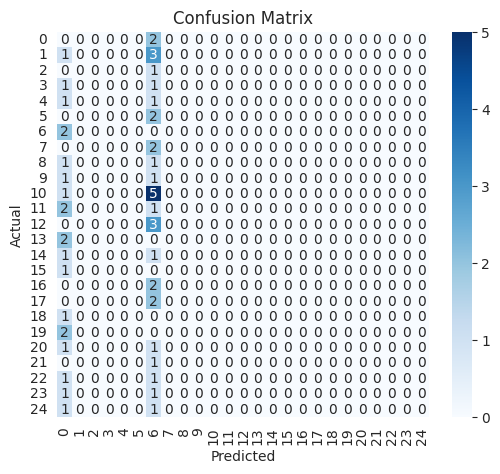

In [ ]:
# ==========================================================
# EMAIL SPAM DETECTION USING MACHINE LEARNING
# ==========================================================

import pandas as pd
import numpy as np
import zipfile
import os

from google.colab import files

# ==========================================================
# UPLOAD DATASET
# ==========================================================

print("Upload CSV or ZIP Dataset")

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

if file_name.endswith(".zip"):

    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        zip_ref.extractall("dataset")

    csv_file = None

    for root, dirs, files_list in os.walk("dataset"):
        for file in files_list:
            if file.endswith(".csv"):
                csv_file = os.path.join(root, file)
                break

    df = pd.read_csv(csv_file, encoding='latin-1')

elif file_name.endswith(".csv"):

    df = pd.read_csv(file_name, encoding='latin-1')

else:
    raise Exception("Upload CSV or ZIP file")

# ==========================================================
# DATASET OVERVIEW
# ==========================================================

print(df.head())

print("\nShape:", df.shape)

print("\nColumns:")
print(df.columns)

# ==========================================================
# CLEAN DATASET
# ==========================================================

df = df.iloc[:, :2]

df.columns = ['label', 'message']

print(df.head())

# ==========================================================
# LABEL ENCODING
# ==========================================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['label'])

# ham = 0
# spam = 1

print(df.head())

# ==========================================================
# TEXT VECTORIZATION
# ==========================================================

from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

X = cv.fit_transform(df['message'])

y = df['label']

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================================
# TRAIN MODEL
# ==========================================================

from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

print("Model Trained Successfully")

# ==========================================================
# PREDICTIONS
# ==========================================================

predictions = model.predict(X_test)

# ==========================================================
# EVALUATION
# ==========================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

accuracy = accuracy_score(y_test, predictions)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, predictions))

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ==========================================================
# TEST CUSTOM EMAIL
# ==========================================================

while True:

    msg = input("\nEnter Email Message (or type exit): ")

    if msg.lower() == "exit":
        break

    data = cv.transform([msg])

    prediction = model.predict(data)[0]

    if prediction == 1:
        print("SPAM EMAIL")
    else:
        print("NOT SPAM")